# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

Open the file linear_regression_example.py from your course material folder. Read
through the script, then copy its contents into a code cell and run it. (Do not re-import
libraries that you already imported at the top of the notebook.)

In [2]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In a code cell, print the slope (model.coef_[0]) and intercept (model.intercept_) of the
fitted model

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In another code cell, add the following prediction code:\
y_pred = model.predict(X_test)\
print('Actual scores: ', list(y_test))\
print('Predicted scores:', list(y_pred.round(1)))

In [4]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In another code cell, add the following evaluation code to find how much of the
variation in your target variable is explained by your model:

In [5]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


what does the R² score mean, and what does it tell you about how well this model fits the data?

    The R² score means how accurate the output is. It tells us that the model fits the data with almost 100% accuracy.

In another code cell, add the following code to visualize the regression line:

C:\Users\luise\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


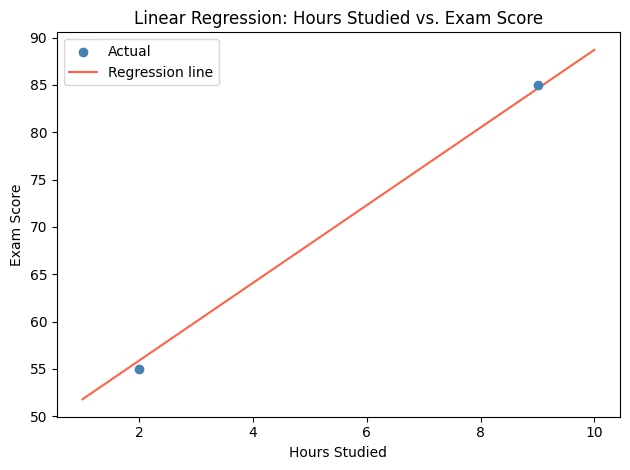

In [6]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

describe what you see: how closely do
the actual data points follow the regression line?

    The data points are very close to the regression line with one point making contact with the regression line

## Lab 2
### Building your own model

In a code cell, create a DataFrame named df_ads and assign to it the following data:\
ad_data = {\
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],\
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]\
}

In [8]:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}
df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


Define your feature matrix X2 using the monthly_ad_spend column (use double
brackets to keep it as a DataFrame), and your target vector y2 using the
monthly_revenue column. Print the shape of X2 and the shape of y2.

In [19]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads[['monthly_revenue']]
print(X2.shape)
print(y2.shape)

(20, 1)
(20, 1)


Split X2 and y2 into training and test sets using train_test_split. Use
test_size=0.2 and random_state=42 to match the approach from Lab 1.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In a separate cell, create a LinearRegression model named model2, fit it to the
training data, and print “Model trained successfully.”

In [21]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Print the slope (model2.coef_[0]) and intercept (model2.intercept_) of the
fitted model. Add a comment interpreting what the slope means in the context of ad
spend and revenue (e.g. “for each additional ___, the predicted ___ increases by __”).

In [23]:
print(f'\nSlope (coefficient): {model2.coef_[0]}')
print(f'Intercept: {model2.intercept_}')
# For each additional ad spend, the predicted revenue increases by 1.96


Slope (coefficient): [1.95590409]
Intercept: [3625.89353039]


### Making predictions and evaluating the model

Use the fitted model to predict revenue for the test set. Print the actual values and
the predicted values side by side (rounded to 2 decimal places).

In [32]:
y_pred = model2.predict(X_test)
print('Actual scores: ', list(y_test['monthly_revenue']))
print('Predicted scores:', np.round(y_pred, 2))

Actual scores:  [4200, 21500, 19400, 5100]
Predicted scores: [[ 4603.85]
 [21229.03]
 [19273.13]
 [ 5581.8 ]]


Calculate and print the R² score for the test set. Then add a markdown cell and give
your interpretation of the result: does the model appear to be a good fit? What
percentage of the variation in revenue is explained by ad spend?

In [33]:
r_squared = model2.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


    The model appears to be a good fit. I would say the missing .2 percent is explained by ad spend 

### Visualizing the results

Text(0, 0.5, 'Monthly Revenue ($)')

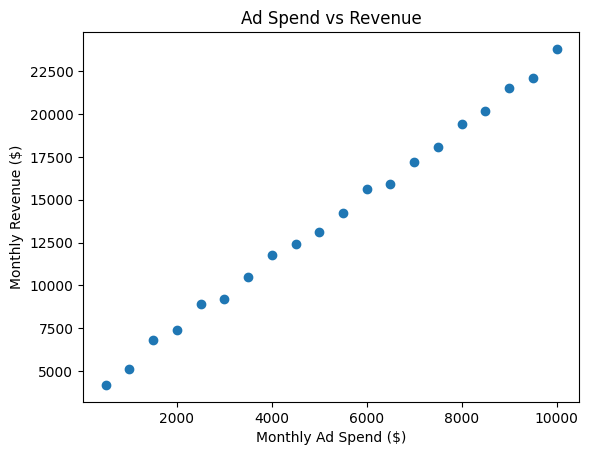

In [36]:
plt.scatter(X2, y2)
plt.title('Ad Spend vs Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')

In another cell, copy and paste the code you used to generate a scatter plot. This
time, add a regression line overlayed on the scatter plot. Use a contrasting color and
add a legend distinguishing the data points from the regression line. Then run the cell
to display the plot.

C:\Users\luise\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


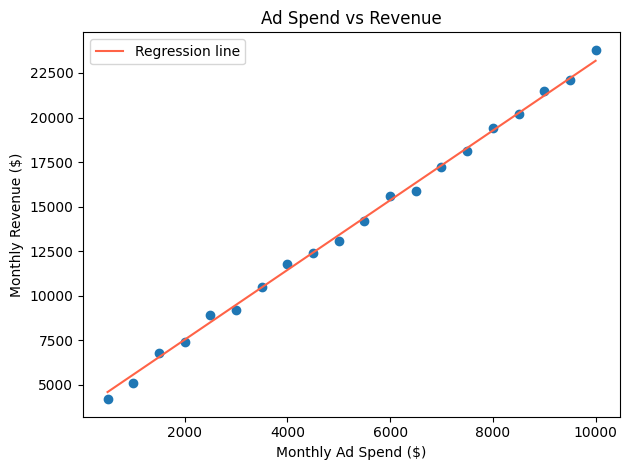

In [37]:
plt.scatter(X2, y2)
plt.title('Ad Spend vs Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')

# Line: model predictions across the full range of X
x_range = np.linspace(
X2['monthly_ad_spend'].min(),
X2['monthly_ad_spend'].max(),
100).reshape(-1, 1)
y_line = model2.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.legend()
plt.tight_layout()
plt.show()

 Does the regression line appear to fit the data well
visually? Does this match what the R² score told you?

    The regression line appears to fit the data well visually. It seems to match what the R^2 score told me.